In [2]:
A_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
A_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]


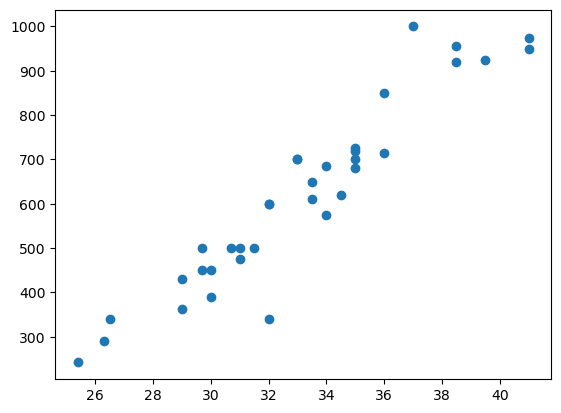

In [3]:
import matplotlib.pyplot as plt
plt.scatter(A_length, A_weight)
plt.show()

In [5]:
B_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
B_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

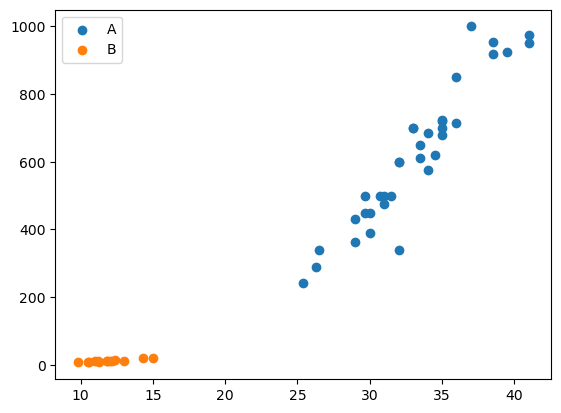

In [9]:
plt.scatter(A_length, A_weight, label='A')
plt.scatter(B_length, B_weight, label='B')
plt.legend()
plt.show()

In [ ]:
length = A_length + B_length
weight = A_weight + B_weight
X = [[a,b] for a,b in zip(length,weight)]  #--> sklearn 은 이런 타입이 와야함.
y = [1]*len(A_length) + [0]*len(B_length)  #class 임의지정

In [20]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X, y)
knn.score(X,y)

1.0

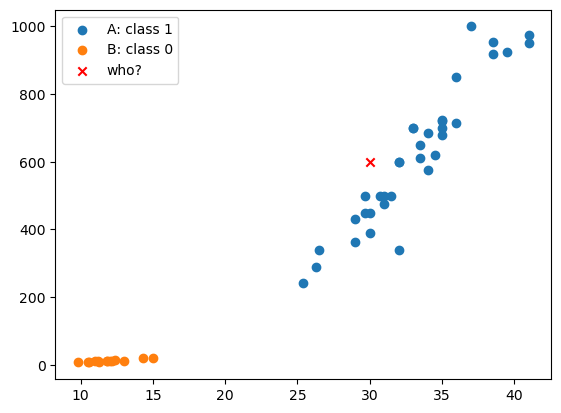

In [19]:
# (30, 600) 일 때 이것은 과연 어느 그룹인가? 그룹 예측
plt.scatter(A_length, A_weight, label='A: class 1')
plt.scatter(B_length, B_weight, label='B: class 0')
plt.scatter(30,600, label='who?', marker='x', color='red')
plt.legend()
plt.show()

In [23]:
#학습을 2D로 했으니, 예측 데이터도 2D로 입력해야함. [[]] --> [] 1차원으로 입력시 오류 발생
knn.predict( [[30,600]] ) 

array([1])

In [27]:
knn = KNeighborsClassifier(n_neighbors=len(X))
knn.fit(X,y)
knn.score(X,y)

0.7142857142857143

In [28]:
len(A_length) / len(X)   


# knn = KNeighborsClassifier(n_neighbors=len(X))
# 그룹1에 대한 값과 상기 score 결과가 동일
# --> 거리기반, 다수결이라서.. 전체 X 중에서 A_length가 많고 가까이 있어서? 전부 그룹1이 투표해서.. 그룹1로..?
# --> 어떤 값이 들어와도 그룹1로 함...  

0.7142857142857143

<span style="font-size:11px">

- KNN에서 n_neighbors가 너무 크면, 모델이 데이터의 “거리 차이”를 무시하고 단순히 “많은 클래스” 쪽으로만 분류하게 됩니다.


| 구분     | K값          | 기준              | 결과             |
| ------ | ----------- | --------------- | -------------- |
| 기본 KNN | 5           | 가까운 5개 이웃의 다수결  | 정확히 분류 (거리 기반) |
| 전체 KNN | len(X)=49   | 전체 데이터 다수결      | 항상 A(1)로 분류됨   |
| 이유     | A 데이터가 더 많음 | 거리 무시되고 다수결만 작용 |                |


In [29]:
knn.predict( [[10,10]] ) # 하기 그래프를 보면 실제는 그룹0에 있어야 하나, 결과를 그룹1로 나옴

array([1])

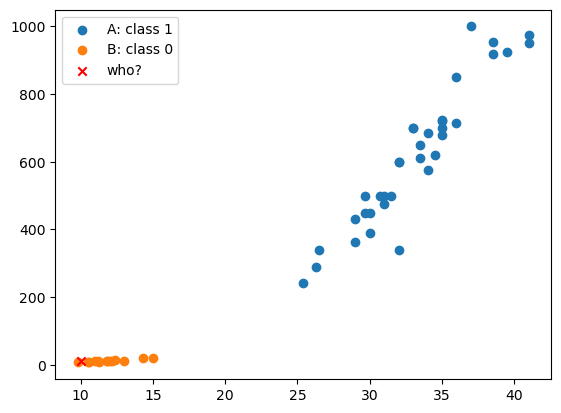

In [30]:
# (10,10) 일 때 이것은 과연 어느 그룹인가? 그룹 예측
plt.scatter(A_length, A_weight, label='A: class 1')
plt.scatter(B_length, B_weight, label='B: class 0')
plt.scatter(10,10, label='who?', marker='x', color='red')
plt.legend()
plt.show()

In [39]:
# 분할 7:3
split_num = int(len(X)*0.7)
X_train, y_train = X[: split_num], y[: split_num]
X_test, y_test = X[split_num :], y[split_num :]

In [33]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn.score (X_test, y_test), knn.score(X_train, y_train)

# score 점수가 낮다 --> 데이터가 잘못되었다. --> 학습용 데이터에 문제가 있다. (클래스가 0은 작고, 1만 많아서)


(0.06666666666666667, 1.0)

In [40]:
import numpy as np
np.unique(y_train, return_counts=True) # 클래스 1만 나옴.

(array([1]), array([34]))

In [44]:
# 분할 8:2
split_num = int(len(X)*0.8)
X_train, y_train = X[: split_num], y[: split_num]
X_test, y_test = X[split_num :], y[split_num :]
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn.score (X_test, y_test), knn.score(X_train, y_train)

np.unique(y_train) # 클래스 0,1 나옴
np.unique(y_train, return_counts=True)



(array([0, 1]), array([ 4, 35]))

- 데이터는 잘 섞여 있어야한다!

In [76]:
# 데이터 섞기
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, stratify=y, test_size=0.3, random_state=42)
knn=KNeighborsClassifier()
knn.fit(X_train,y_train)
print(f'train score{knn.score(X_train, y_train)}, test score{knn.score(X_test, y_test)}') # score : 분류모델 --> accuracy, 회귀모델 --> 결정계수
print(f'predict {knn.predict ([[25,150]])}')
predict_point = knn.kneighbors([[25,150]])
print(predict_point)

train score1.0, test score1.0
predict [0]
(array([[130.48375378, 130.73859415, 138.32150953, 138.39320793,
        140.80142045]]), array([[29, 16, 26,  0, 11]]))


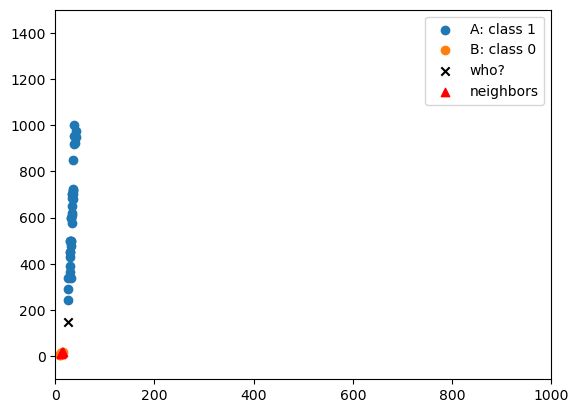

In [70]:
plt.scatter(A_length, A_weight, label='A: class 1')
plt.scatter(B_length, B_weight, label='B: class 0')
plt.scatter(25,150, label='who?', marker='x', color='black')
distances, indexs = knn.kneighbors([[25,150]])
plt.scatter(np.array(X_train)[indexs,0], np.array(X_train)[indexs,1], label='neighbors', marker='^', color='red')
plt.xlim(0,1000)
plt.ylim(-100,1500)
plt.legend()
plt.show()
# 하기와 같은 x,y축 그래프 상태로 보면 모델이 왜 neighbors를 선택했는지 이해가 갈순있음.. 

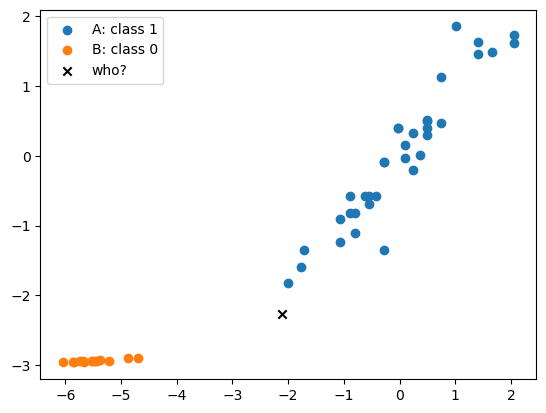

In [73]:
from sklearn.preprocessing import StandardScaler
# 스케일링 (정규화)
scaler = StandardScaler()
convert_array_a= np.array(list(zip(A_length, A_weight)))
convert_array_b= np.array(list(zip(B_length, B_weight)))
scaled_a = scaler.fit_transform(convert_array_a)
scaled_b = scaler.transform(convert_array_b)


plt.scatter(scaled_a[:,0], scaled_a[:,1], label='A: class 1')
plt.scatter(scaled_b[:,0], scaled_b[:,1], label='B: class 0')
distances, indexs = knn.kneighbors([[25,150]])
who_point = scaler.transform([[25,150]])
plt.scatter(who_point[:,0], who_point[:,1], label='who?', marker='x', color='black')
plt.legend()
plt.show()

In [77]:
# 데이터 섞기
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, stratify=y, test_size=0.3, random_state=42)

# 정규화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 학습
knn=KNeighborsClassifier()
knn.fit(X_train_scaled,y_train)
print(knn.score(X_train_scaled, y_train), knn.score(X_test_scaled, y_test))
print(f'predict {knn.predict ([[25,150]])}')
predict_point = knn.kneighbors([[25,150]])
print(predict_point)

1.0 1.0
predict [1]
(array([[150.1948252 , 150.20925269, 150.38738079, 150.6745487 ,
        151.07696908]]), array([[13, 33, 18, 20, 25]]))


In [90]:
# np.array(X_train)
np.array(y_train) == 1

array([False,  True,  True,  True,  True,  True, False,  True,  True,
       False,  True, False,  True,  True,  True,  True, False,  True,
        True, False,  True, False,  True, False,  True,  True, False,
        True,  True, False,  True,  True,  True,  True])

In [91]:
predicted_points = scaler.transform([[25,150]])
predicted_points[:,0][0]

np.float64(-0.20071490885653048)

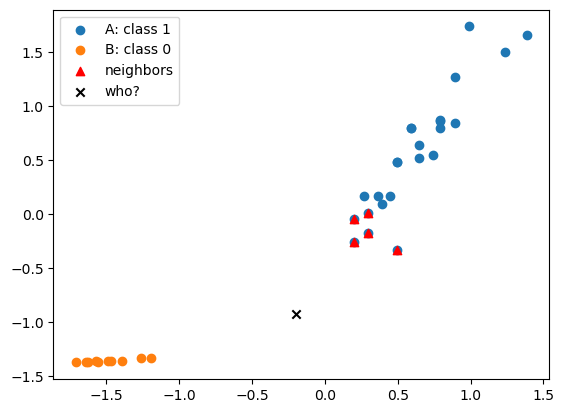

In [89]:

plt.scatter(X_train_scaled[np.array(y_train) == 1,0], 
            X_train_scaled[np.array(y_train)==1,1], label='A: class 1')

plt.scatter(X_train_scaled[np.array(y_train) == 0,0], 
            X_train_scaled[np.array(y_train)==0,1], label='B: class 0')

plt.scatter(X_train_scaled[indexs,0],X_train_scaled[indexs,1], label='neighbors', marker='^', color='red')

predicted_points = scaler.transform([[25,150]])
_, indexs = knn.kneighbors(predicted_points)
plt.scatter(predicted_points[:,0],predicted_points[:,1], label='who?', marker='x', color='black')

plt.legend()
plt.show()

In [103]:
################## 최종 실습 ##################################################################

A_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
A_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]
B_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
B_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X = np.array (list (zip (A_length+B_length, A_weight+B_weight)))
y = np.array([1]*len(A_length) + [0]*len(B_length))
X.shape, y.shape

# 데이터를 잘 섞어서 분할
X_train, X_test, y_train, y_test = train_test_split(X,y, stratify=y, random_state=42, test_size=0.3)

# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 학습
knn = KNeighborsClassifier()
knn.fit(X_train_scaled,y_train)

# 예측 [25,150]을 predict 하면 1이 출력되는지 확인
scaler.transform ([[25,150]])
knn.predict([[25,150]])



array([1])

In [106]:
######### pipline #####################################
from sklearn.pipeline import Pipeline

pipe = Pipeline ([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

pipe.fit(X_train, y_train)
pipe.predict([[25,150]])

array([1])

## 딥러닝 모델

- 현재 순서:
    1. 시드 고정
    2. X, y → Tensor (X_tensor, y_tensor)
    3. train/test 분리 (train_test_split)
모델 정의 (nn.Sequential)

device, learning rate, epochs 설정

손실함수, 옵티마이저 정의

train Tensor 재변환 (중복)

test Tensor 변환

학습 루프 (optimizer.zero_grad → forward → loss → backward → step → train accuracy)

평가 (with torch.no_grad() → test accuracy)

✅ 순서 자체는 논리적으로 맞음

학습 전에 모델 정의, 손실, 옵티마이저 설정 → 정확함

학습 루프 안에서 GPU로 이동 → 가능

평가 단계에서 no_grad → 올바름

In [207]:
################ 딥러닝 ===============================


# 딥러닝 : 클래스 (nn.Module), 조립 (nn.Sequential)
import torch
import torch.nn as nn
import torch.optim as optim

X.shape  # (49, 2) --> input 신경망 2개
torch.manual_seed(42)  # 고정시드 설정 / 이거 안하면 돌릴때마다 accuracy 계속 바뀜


# 데이터 분리
X_train, X_test, y_train, y_test \
    = train_test_split(X, y, random_state=42, stratify=y, test_size=0.2)
# 입력데이터를 tensor 형태로 변경
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.long).to(device)


# 모델 
model = nn.Sequential(
    nn.Linear(2, 8),
    nn.ReLU(),
    nn.Linear(8, 4),
    nn.ReLU(),
    nn.Linear(4, 2)    # output
    # nn.Softmax()      # Softmax 단일정답일 때! / 다중클래스 선택이면 시그모이드
)

# 하이퍼 파라미터 : 디바이스, learning rate, epoch
device = "cuda" if torch.cuda.is_available() else 'cpu'
lr = 1e-03
epochs = 300
model.to(device)


# 손실함수
criterian = nn.CrossEntropyLoss()   #내부에 [softmax + log 손실계산] 있음 --> model에서 softmax 삭제

# 옵티마이저
optimizer = optim.Adam(model.parameters(), lr=lr)



# 학습 루프 (batch = full dataset)
for epoch in range(epochs):
    optimizer.zero_grad()
    X_train, y_train = X_train.to(device), y_train.to(device)
    preds = model(X_train)
        #print(type(preds), preds, type(y_train))
    loss = criterian(preds, y_train)
    loss.backward()
    optimizer.step()
  
    yhat = torch.argmax(preds,dim=1)
    acc = (yhat == y_train).float().mean()
    if (epoch+1) % 10 == 0:
        print (f' epoch : {epoch+1}, accuracy : {acc.item():.4f}, loss : {loss.item():.4f} ')


# # 평가 단계(test)
# with torch.no_grad():
#     preds_test = model(X_test)
#     yhat_test = torch.argmax(preds_test, dim=1)
#     test_acc = (yhat_test == y_test).float().mean()
    
# print(f"\nTest Accuracy: {test_acc.item():.4f}")





 epoch : 10, accuracy : 0.7179, loss : 0.3769 
 epoch : 20, accuracy : 0.7179, loss : 0.2690 
 epoch : 30, accuracy : 0.9487, loss : 0.1896 
 epoch : 40, accuracy : 1.0000, loss : 0.1359 
 epoch : 50, accuracy : 1.0000, loss : 0.1020 
 epoch : 60, accuracy : 1.0000, loss : 0.0783 
 epoch : 70, accuracy : 1.0000, loss : 0.0623 
 epoch : 80, accuracy : 1.0000, loss : 0.0516 
 epoch : 90, accuracy : 1.0000, loss : 0.0431 
 epoch : 100, accuracy : 1.0000, loss : 0.0365 
 epoch : 110, accuracy : 1.0000, loss : 0.0311 
 epoch : 120, accuracy : 1.0000, loss : 0.0267 
 epoch : 130, accuracy : 1.0000, loss : 0.0231 
 epoch : 140, accuracy : 1.0000, loss : 0.0201 
 epoch : 150, accuracy : 1.0000, loss : 0.0176 
 epoch : 160, accuracy : 1.0000, loss : 0.0156 
 epoch : 170, accuracy : 1.0000, loss : 0.0138 
 epoch : 180, accuracy : 1.0000, loss : 0.0124 
 epoch : 190, accuracy : 1.0000, loss : 0.0111 
 epoch : 200, accuracy : 1.0000, loss : 0.0100 
 epoch : 210, accuracy : 1.0000, loss : 0.0091 
 

In [242]:

# [25,150] 예측 결과

# 새 입력값
new_data = np.array([[25, 150]])

# # 1) 스케일링 (학습때 쓴 scaler 사용)
# new_data_scaled = scaler.transform(new_data)

# 2) Tensor로 변환
new_tensor = torch.tensor(new_data, dtype=torch.float32).to(device)

with torch.no_grad():  # 평가 단계이므로 gradient 계산 불필요
    preds = model(new_tensor)           # forward
    yhat = torch.argmax(preds, dim=1)   # 가장 높은 클래스 선택

print("예측 클래스:", yhat.item())


예측 클래스: 0


In [228]:
X_test[1], y_test[1]

(tensor([11.8000, 10.0000]), tensor(0))

In [229]:
torch.argmax(model(X_test[1]))

tensor(0)

In [118]:
y_train.shape, X_train.shape

(torch.Size([39]), torch.Size([39, 2]))

In [120]:
y_train

tensor([0., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0.,
        1., 1., 1., 1., 0., 1., 1., 0., 1., 0., 1., 0., 1., 1., 1., 1., 0., 1.,
        0., 1., 1.])

In [122]:
print(type(preds), preds, type(y_train))

<class 'torch.Tensor'> tensor([[ 2.2175e-01,  5.9901e-02],
        [-8.7606e+00,  1.7689e+01],
        [ 2.2175e-01,  5.9901e-02],
        [ 2.2175e-01,  5.9901e-02],
        [-4.1334e+01,  7.3750e+01],
        [-3.0754e+01,  5.5615e+01],
        [-2.5113e+01,  4.5836e+01],
        [-1.2760e+01,  2.5060e+01],
        [-2.9566e+01,  5.3617e+01],
        [-2.5113e+01,  4.5836e+01],
        [-1.8215e+01,  3.4010e+01],
        [-2.0591e+01,  3.8005e+01],
        [-2.7340e+01,  4.9727e+01],
        [-2.5439e+01,  4.6530e+01],
        [-1.8186e+01,  3.3989e+01],
        [-3.9809e+01,  7.1283e+01],
        [ 2.2175e-01,  5.9901e-02],
        [ 2.2175e-01,  5.9901e-02],
        [-3.6594e+01,  6.5534e+01],
        [-1.4151e+01,  2.7107e+01],
        [-2.0492e+01,  3.7936e+01],
        [-2.0412e+01,  3.7880e+01],
        [ 2.2175e-01,  5.9901e-02],
        [-1.9274e+01,  3.5917e+01],
        [-3.9671e+01,  7.0953e+01],
        [ 2.2175e-01,  5.9901e-02],
        [-2.9765e+01,  5.3757e+01],
     

In [199]:
# 시그모이드 vs softmax
import torch
import torch.nn.functional as F

#
output = torch.tensor ([3.0, 1.0, 0.1])

# sigmoid : 개별적으로 적용 (0~1) 각 요소가 독립적이어서 여러개가 정답일 경우
print(F.sigmoid(output), sum(F.sigmoid(output)))
       
# softmax :전체의 합이 1 - 서로 경쟁하는 구조
print(F.softmax(output), sum(F.softmax(output)))


tensor([0.9526, 0.7311, 0.5250]) tensor(2.2086)
tensor([0.8401, 0.1137, 0.0462]) tensor(1.)


C:\Users\playdata2\AppData\Local\Temp\ipykernel_3972\771540913.py:12: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  print(F.softmax(output), sum(F.softmax(output)))
